### PEM voltage cutoff

This notebook estimates the minimum usable PEM fuel cell voltage from the discharge tests.

The idea is simple: during discharge the voltage is stable for a while, and then it starts dropping quickly. I use the voltage where this fast drop begins as the collapse point. The EMS cutoff is the median of the detected collapse voltages.

In [8]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../../data/PEM_test/charge_discharge")

charge_test_files = [
    "discharge_020A_30s_r1.csv",
    "discharge_020A_60s_r1.csv",
    "discharge_020A_120s_r1.csv",
    "discharge_030A_30s_r1.csv",
    "discharge_030A_60s_r1.csv",
    "discharge_030A_120s_r1.csv",
    "discharge_040A_30s_r1.csv",
    "discharge_040A_60s_r1.csv",
    "discharge_040A_120s_r1.csv",
    "discharge_PEM_full.csv",
]

# Correction factors from the calibration data.
PEM_CURRENT_CORRECTION = lambda i: 0.843 * i + 0.001
PEM_VOLTAGE_CORRECTION = lambda v: v - 0.064

# Same collapse settings as the larger .py analysis, but kept here as simple variables.
rolling_window = 5
startup_ignore_s = 20
dvdt_limit = -0.005
points_in_a_row = 3

#### Load and correct one file

In [9]:
def parse_test_name(file_name):
    current_match = re.search(r"(\d{3})A", file_name)
    time_match = re.search(r"_(\d+)s_", file_name)

    current_A = int(current_match.group(1)) / 100 if current_match else np.nan
    charge_time_s = int(time_match.group(1)) if time_match else np.nan

    return current_A, charge_time_s


def load_and_correct_file(file_name):
    df = pd.read_csv(DATA_DIR / file_name)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp").reset_index(drop=True)

    df["time_s"] = (
        df["timestamp"] - df["timestamp"].iloc[0]
    ).dt.total_seconds()

    df["pem_current_A"] = PEM_CURRENT_CORRECTION(
        df["ina4_current_mA"] / 1000
    )

    df["pem_voltage_V"] = PEM_VOLTAGE_CORRECTION(
        df["ina4_bus_V"]
    )

    df["pem_power_W"] = df["pem_voltage_V"] * df["pem_current_A"]

    return df

#### Extract only the PEM discharge part

In [10]:
def extract_discharge_part(df):
    discharge = df[df["scenario"] == 6].copy()
    discharge = discharge.sort_values("timestamp").reset_index(drop=True)

    # Start when the PEM is actually delivering current.
    active = discharge["pem_current_A"] < -0.005

    if not active.any():
        return discharge.iloc[0:0].copy()

    start_idx = active.idxmax()
    discharge = discharge.loc[start_idx:].reset_index(drop=True)

    # Stop if the current has been near zero for a few samples.
    near_zero = abs(discharge["pem_current_A"]) < 0.005
    near_zero_count = near_zero.rolling(3).sum()

    if (near_zero_count == 3).any():
        end_idx = (near_zero_count == 3).idxmax() - 2
        discharge = discharge.loc[:end_idx - 1].copy()

    discharge["discharge_time_s"] = (
        discharge["timestamp"] - discharge["timestamp"].iloc[0]
    ).dt.total_seconds()

    return discharge.reset_index(drop=True)

#### Find when the voltage starts collapsing

In [11]:
def find_collapse_point(discharge):
    if len(discharge) < rolling_window + points_in_a_row:
        return None

    time_s = discharge["discharge_time_s"].to_numpy()
    voltage = discharge["pem_voltage_V"].to_numpy()

    smooth_voltage = (
        pd.Series(voltage)
        .rolling(rolling_window, center=True, min_periods=1)
        .median()
        .to_numpy()
    )

    dvdt = np.gradient(smooth_voltage, time_s)

    duration_s = time_s[-1] - time_s[0]
    ignore_until_s = max(startup_ignore_s, 0.20 * duration_s)

    collapse = (time_s >= ignore_until_s) & (dvdt <= dvdt_limit)

    # Require the collapse condition to be true for several points in a row.
    collapse_count = np.convolve(
        collapse.astype(int),
        np.ones(points_in_a_row, dtype=int),
        mode="valid",
    )

    matches = np.where(collapse_count == points_in_a_row)[0]

    if len(matches) == 0:
        return None

    i = matches[0]

    return {
        "collapse_index": i,
        "collapse_time_s": time_s[i],
        "collapse_voltage_V": smooth_voltage[i],
        "collapse_dvdt_V_per_s": dvdt[i],
    }

#### Run the calculation for all discharge tests

In [12]:
rows = []
curves = []

for file_name in charge_test_files:
    current_A, charge_time_s = parse_test_name(file_name)
    df = load_and_correct_file(file_name)
    discharge = extract_discharge_part(df)
    collapse_point = find_collapse_point(discharge)

    curves.append({
        "file": file_name,
        "current_A": current_A,
        "charge_time_s": charge_time_s,
        "discharge": discharge,
        "collapse_point": collapse_point,
    })

    if collapse_point is not None:
        rows.append({
            "file": file_name,
            "charge_current_A": current_A,
            "charge_time_s": charge_time_s,
            **collapse_point,
        })

collapse_points = pd.DataFrame(rows)
voltage_cutoff_V = collapse_points["collapse_voltage_V"].median()

print(f"Estimated voltage cutoff = {voltage_cutoff_V:.4f} V")
collapse_points

Estimated voltage cutoff = 0.5335 V


,file,charge_current_A,charge_time_s,collapse_index,collapse_time_s,collapse_voltage_V,collapse_dvdt_V_per_s
0,discharge_020A_30s_r1.csv,0.2,30.0,121,128.0,0.5823,-0.00750
1,discharge_020A_60s_r1.csv,0.2,60.0,123,129.0,0.5860,-0.00500
2,discharge_020A_120s_r1.csv,0.2,120.0,380,401.0,0.4772,-0.00625
3,discharge_030A_30s_r1.csv,0.3,30.0,112,119.0,0.5048,-0.00500
4,discharge_030A_60s_r1.csv,0.3,60.0,183,193.0,0.5810,-0.00560
5,discharge_030A_120s_r1.csv,0.3,120.0,398,420.0,0.5035,-0.00505
6,discharge_040A_30s_r1.csv,0.4,30.0,146,154.0,0.5760,-0.00685
7,discharge_040A_60s_r1.csv,0.4,60.0,260,274.0,0.5385,-0.00625
8,discharge_040A_120s_r1.csv,0.4,120.0,421,444.0,0.5285,-0.00560
9,discharge_PEM_full.csv,NaN,NaN,609,643.0,0.3585,-0.00565


#### Plot the detected collapse points

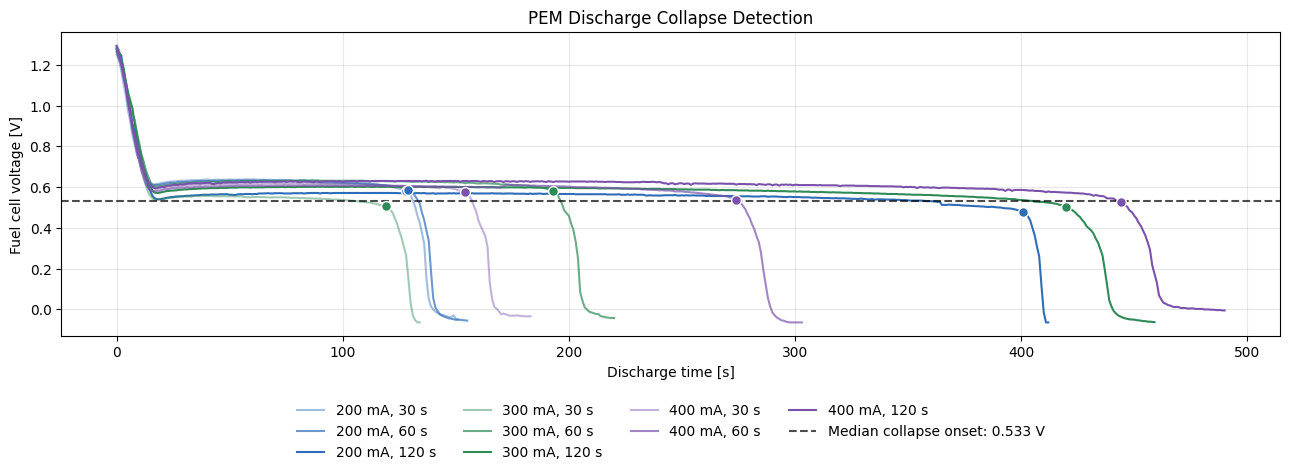

In [15]:
colors = {
    0.2: "#2F6DB8",
    0.3: "#2E8B57",
    0.4: "#7B52AB",
}

def line_alpha(charge_time_s):
    if charge_time_s == 30:
        return 0.45
    if charge_time_s == 60:
        return 0.70
    return 1.0


plt.figure(figsize=(13, 5))

for curve in curves:
    discharge = curve["discharge"]
    current_A = curve["current_A"]
    charge_time_s = curve["charge_time_s"]

    if len(discharge) < 2 or pd.isna(current_A):
        continue

    label = f"{int(current_A * 1000)} mA, {int(charge_time_s)} s"
    color = colors[current_A]

    plt.plot(
        discharge["discharge_time_s"],
        discharge["pem_voltage_V"],
        color=color,
        alpha=line_alpha(charge_time_s),
        label=label,
    )

    point = curve["collapse_point"]
    if point is not None:
        plt.scatter(
            point["collapse_time_s"],
            point["collapse_voltage_V"],
            color=color,
            edgecolor="white",
            s=50,
            zorder=5,
        )

plt.axhline(
    voltage_cutoff_V,
    color="black",
    linestyle="--",
    linewidth=1.5,
    alpha=0.7,
    label=f"Median collapse onset: {voltage_cutoff_V:.3f} V",
)

plt.xlabel("Discharge time [s]")
plt.ylabel("Fuel cell voltage [V]")
plt.title("PEM Discharge Collapse Detection")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=4, frameon=False)
plt.tight_layout()
plt.show()

#### Value for EMS code

In [14]:
print(f"const float PEM_MIN_USABLE_VOLTAGE = {voltage_cutoff_V:.4f};")

const float PEM_MIN_USABLE_VOLTAGE = 0.5335;
